In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
car_auction = pd.read_csv("car_auction_train.csv")

In [3]:
car_auction.head()

,year,make,model,trim,body,transmission,state,condition,odometer,color,interior,sellingprice
0,2012,Kia,Soul,+,Wagon,automatic,ne,4.0,53070.0,gray,black,10100
1,2012,Honda,Civic,LX,Sedan,automatic,ga,2.6,45085.0,gray,gray,10300
2,2002,Honda,Civic,EX,Sedan,automatic,ca,2.2,136649.0,black,gray,3300
3,2002,Dodge,Grand Caravan,Sport,Minivan,automatic,oh,1.9,156991.0,silver,gray,600
4,2010,Chevrolet,Silverado 1500,LT,Crew Cab,NaN,fl,3.4,42421.0,blue,black,21100


In [4]:
car_auction.isnull().sum()

year                0
make             8287
model            8372
trim             8570
body            10593
transmission    52299
state               0
condition        9437
odometer           69
color           20361
interior        14155
sellingprice        0
dtype: int64

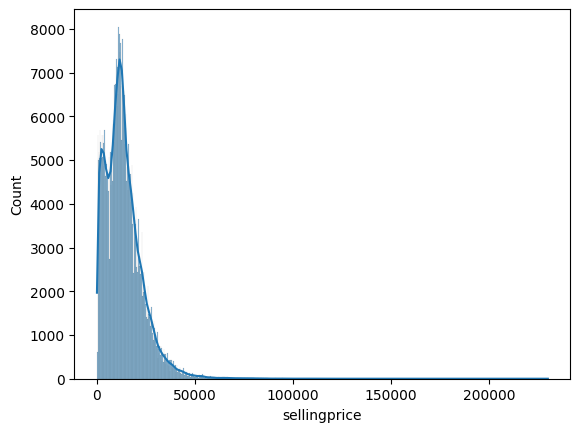

In [5]:
sns.histplot(car_auction["sellingprice"],kde=True)
plt.show()

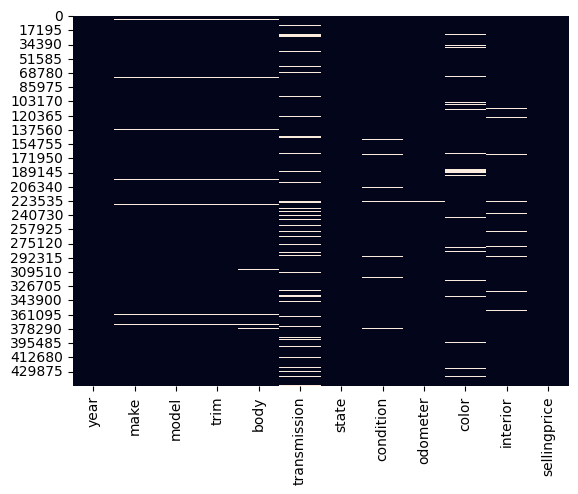

In [6]:
sns.heatmap(car_auction.isnull(),cbar=False)
plt.show()

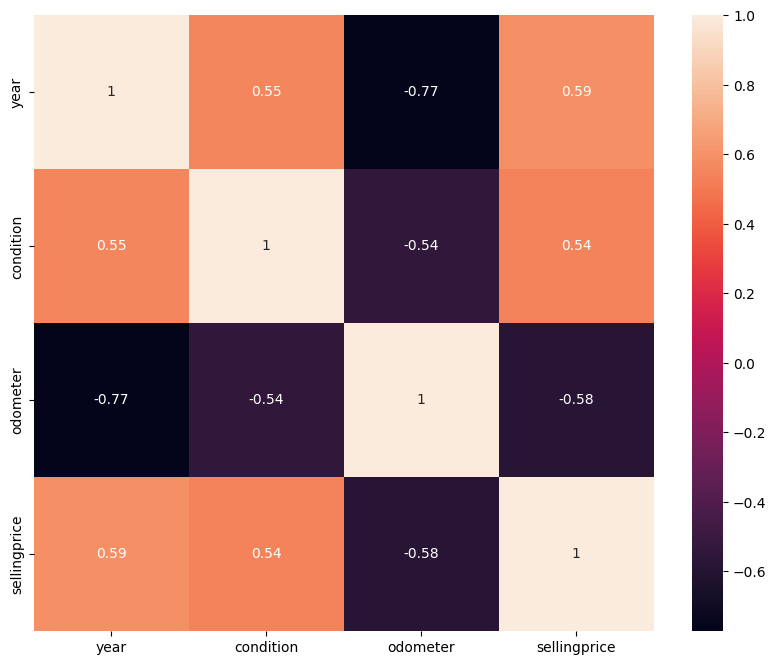

In [7]:
plt.figure(figsize=(10,8))
sns.heatmap(car_auction.corr(numeric_only=True),annot=True)
plt.show()

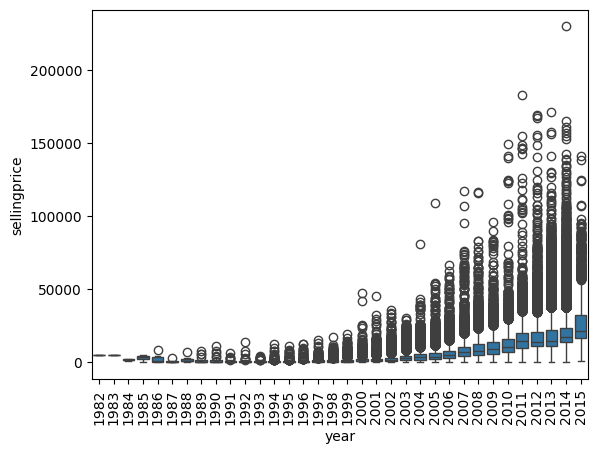

In [8]:
sns.boxplot(x=car_auction["year"], y=car_auction["sellingprice"])
plt.xticks(rotation=90)
plt.show()

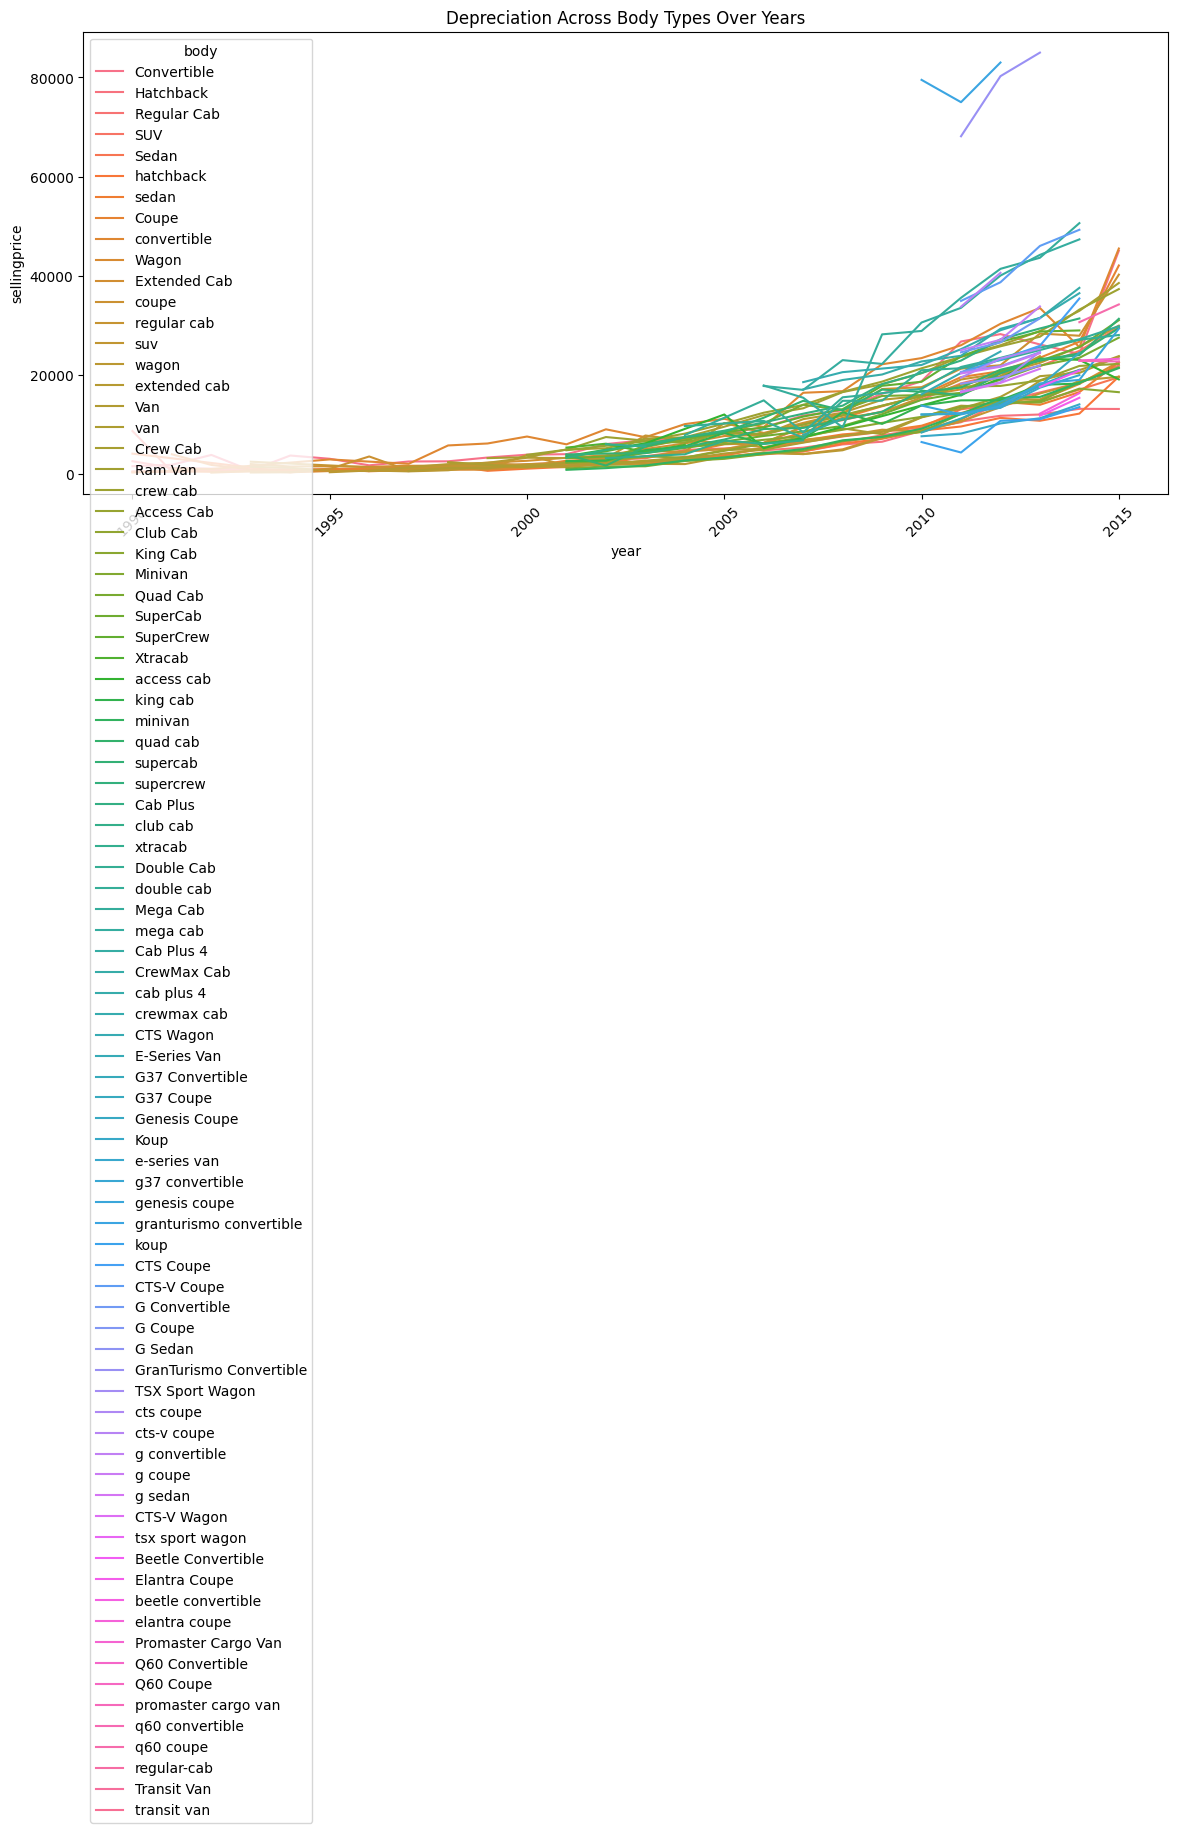

In [9]:
avg_price = car_auction.groupby(['year', 'body'])['sellingprice'].mean().reset_index()

plt.figure(figsize=(14,6))
sns.lineplot(data=avg_price, x='year', y='sellingprice', hue='body')

plt.title("Depreciation Across Body Types Over Years")
plt.xticks(rotation=45)
plt.show()

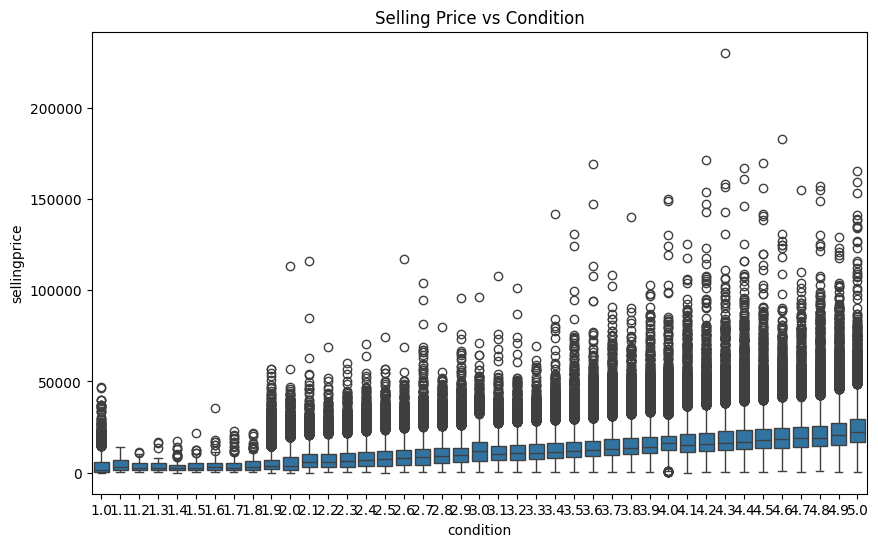

In [10]:
plt.figure(figsize=(10,6))

sns.boxplot(
    x=car_auction['condition'],
    y=car_auction['sellingprice']
)

plt.title("Selling Price vs Condition")

plt.show()

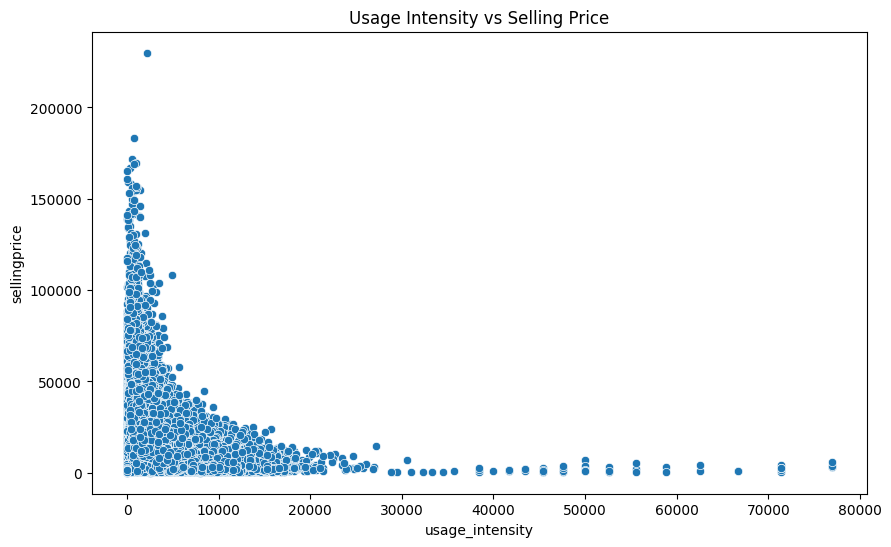

In [11]:
current_year = 2026

car_auction['car_age'] = current_year - car_auction['year']

car_auction['usage_intensity'] = (
    car_auction['odometer'] /
    (car_auction['car_age'] + 1)
)
plt.figure(figsize=(10,6))

sns.scatterplot(
    x=car_auction['usage_intensity'],
    y=car_auction['sellingprice']
)

plt.title("Usage Intensity vs Selling Price")
plt.show()

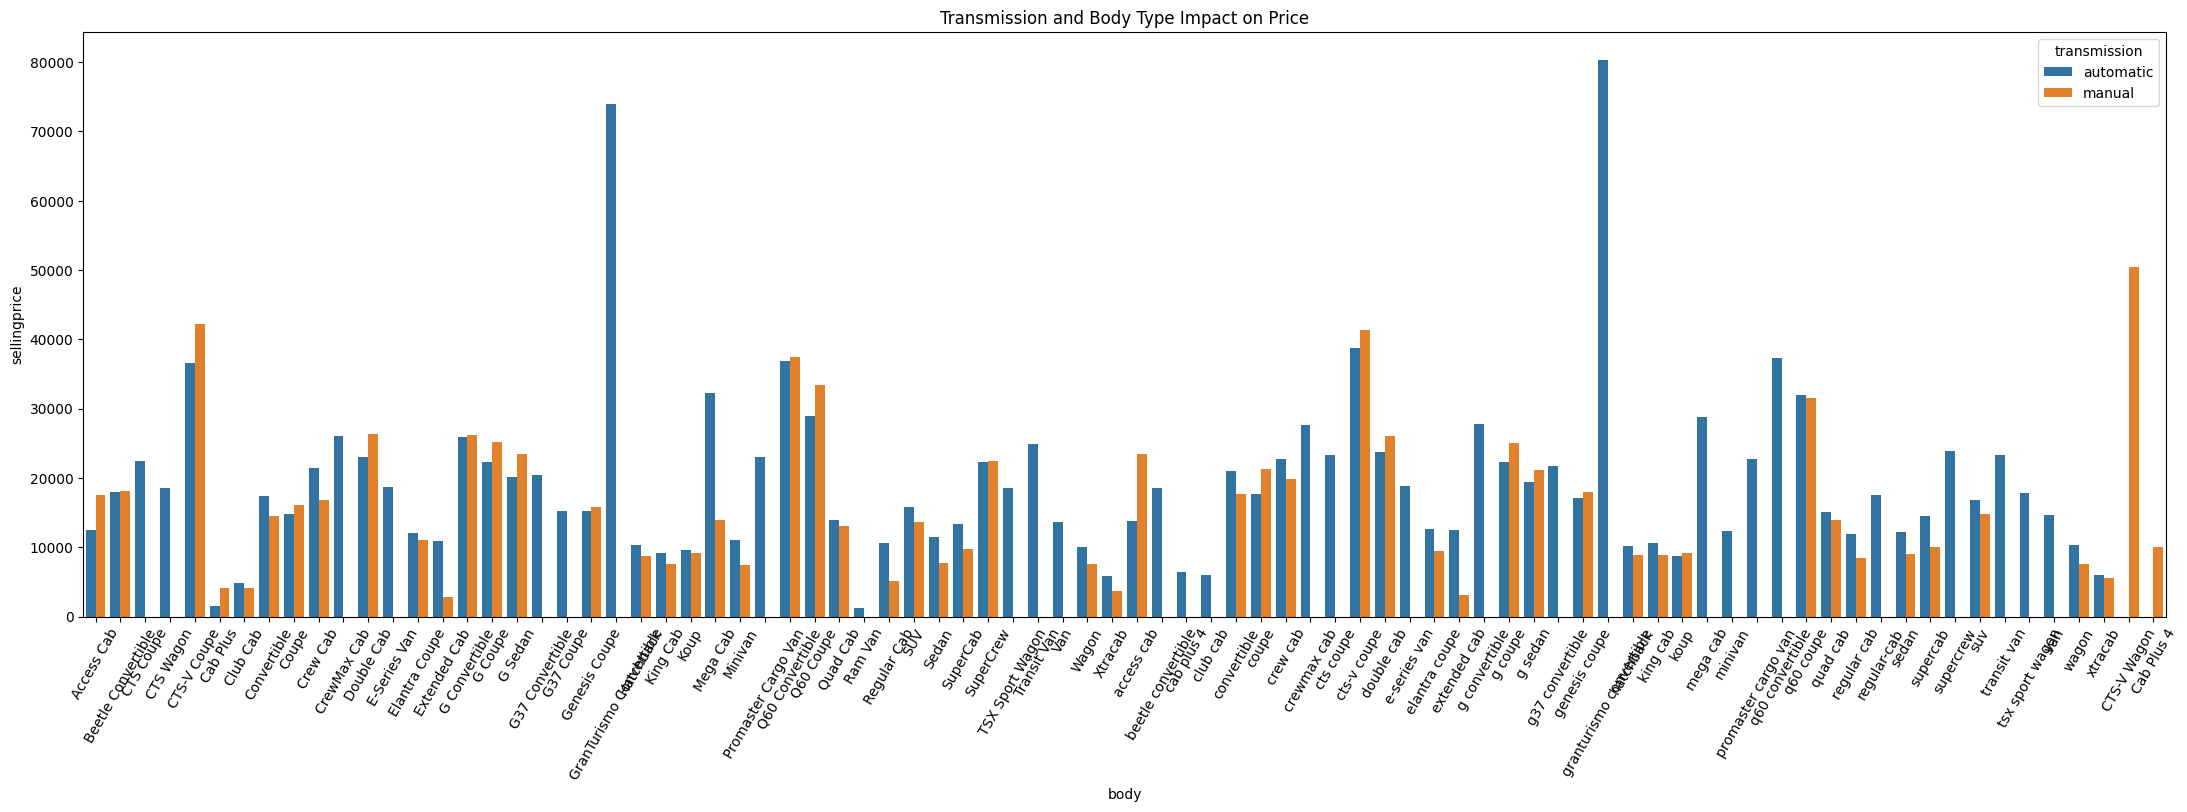

In [14]:
combo_price = car_auction.groupby(
    ['transmission', 'body']
)['sellingprice'].mean().reset_index()
plt.figure(figsize=(22,8))

sns.barplot(
    data=combo_price,
    x='body',
    y='sellingprice',
    hue='transmission'
)

plt.xticks(rotation=60)

plt.tight_layout()

plt.title(
    "Transmission and Body Type Impact on Price"
)

plt.show()